<a href="https://colab.research.google.com/github/springboardmentor14065l/Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/blob/Nikhil-yadav/week%205-6/week_5_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/energy.csv')

# Basic Info
print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df.describe())

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Sort by time
df = df.sort_values('timestamp')

# Check missing values
print(df.isnull().sum())

Shape: (100000, 8)
   Home ID Appliance Type  Energy Consumption (kWh)   Time        Date  \
0       94         Fridge                      0.20  21:12  2023-12-02   
1      435           Oven                      0.23  20:11  2023-08-06   
2      466     Dishwasher                      0.32  06:39  2023-11-21   
3      496         Heater                      3.92  21:56  2023-01-21   
4      137      Microwave                      0.44  04:31  2023-08-26   

   Outdoor Temperature (°C)  Season  Household Size  
0                      -1.0    Fall               2  
1                      31.1  Summer               5  
2                      21.3    Fall               3  
3                      -4.2  Winter               1  
4                      34.5  Summer               5  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------  

In [ ]:
# Fill missing values using forward fill
df.fillna(method='ffill', inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)


/tmp/ipython-input-3637086482.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df.set_index('timestamp', inplace=True)

In [ ]:
df_hourly = df.resample('H').sum()

/tmp/ipython-input-385839458.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').sum()


In [ ]:
train_size = int(len(df_hourly) * 0.7)
val_size = int(len(df_hourly) * 0.15)

train = df_hourly[:train_size]
val = df_hourly[train_size:train_size+val_size]
test = df_hourly[train_size+val_size:]


In [ ]:
df_hourly['hour'] = df_hourly.index.hour#milestone2
df_hourly['day'] = df_hourly.index.day
df_hourly['month'] = df_hourly.index.month
df_hourly['day_of_week'] = df_hourly.index.dayofweek


In [ ]:
df_hourly['lag_1'] = df_hourly.iloc[:,0].shift(1)
df_hourly['lag_24'] = df_hourly.iloc[:,0].shift(24)


In [ ]:
df_hourly['rolling_mean_24'] = df_hourly.iloc[:,0].rolling(window=24).mean()

df_hourly.dropna(inplace=True)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Assuming 'Energy Consumption (kWh)' is the intended target variable
y = df_hourly['Energy Consumption (kWh)']
# Select only numeric columns for features and exclude the target variable
# This robustly handles any non-numeric columns resulting from previous operations
X = df_hourly.select_dtypes(include=np.number).drop(columns=['Energy Consumption (kWh)'])

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae)
print("Linear Regression RMSE:", rmse)

Linear Regression MAE: 3.2550269000312246
Linear Regression RMSE: 4.143479384968137


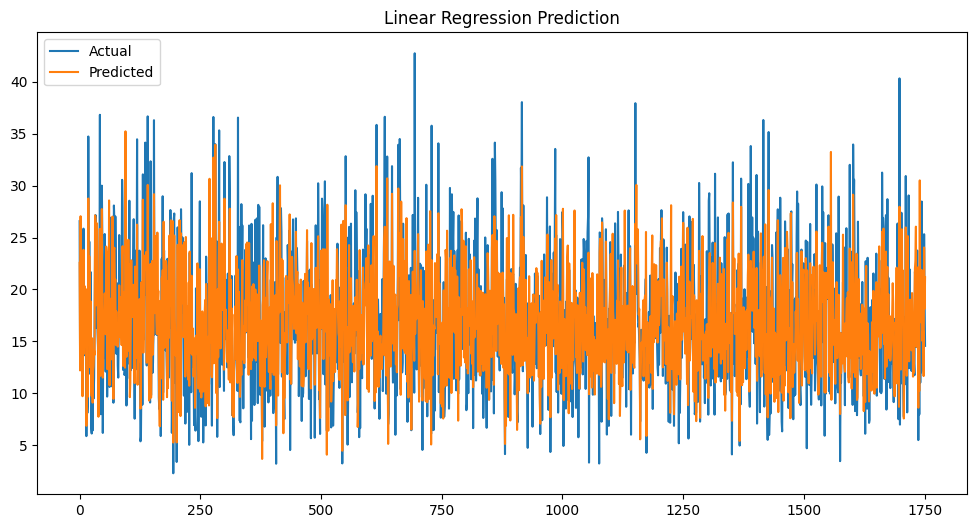

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_lr, label='Predicted')
plt.legend()
plt.title("Linear Regression Prediction")
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_hourly.iloc[:,0].values.reshape(-1,1))


In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24
X_seq, y_seq = create_sequences(scaled_data, seq_length)

split = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

batch_sizes = [16, 32]
epochs_list = [10, 20]
learning_rates = [0.001, 0.0005]

for batch in batch_sizes:
    for epoch in epochs_list:
        for lr in learning_rates:

            model = Sequential()
            model.add(LSTM(50, return_sequences=True, input_shape=(seq_length,1)))
            model.add(LSTM(50))
            model.add(Dense(1))

            optimizer = Adam(learning_rate=lr)
            model.compile(optimizer=optimizer, loss='mse')

            model.fit(X_train_seq, y_train_seq,
                      epochs=epoch,
                      batch_size=batch,
                      verbose=0)

            y_pred = model.predict(X_test_seq)

            y_test_inv = scaler.inverse_transform(y_test_seq)
            y_pred_inv = scaler.inverse_transform(y_pred)

            mae = mean_absolute_error(y_test_inv, y_pred_inv)
            rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
            r2 = r2_score(y_test_inv, y_pred_inv)

            results.append((batch, epoch, lr, mae, rmse, r2))

# Sort by lowest RMSE
results = sorted(results, key=lambda x: x[4])

print("Best Hyperparameters:")
print("Batch:", results[0][0])
print("Epoch:", results[0][1])
print("Learning Rate:", results[0][2])
print("MAE:", results[0][3])
print("RMSE:", results[0][4])
print("R2:", results[0][5])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Best Hyperparameters:
Batch: 32
Epoch: 20
Learning Rate: 0.001
MAE: 782.5661723051792
RMSE: 977.4371130188359
R2: -0.00030098159149938297


In [ ]:
best_batch, best_epoch, best_lr, _, _, _ = results[0]

final_model = Sequential()
final_model.add(LSTM(50, return_sequences=True, input_shape=(seq_length,1)))
final_model.add(LSTM(50))
final_model.add(Dense(1))

final_model.compile(optimizer=Adam(learning_rate=best_lr), loss='mse')

final_model.fit(X_train_seq, y_train_seq,
                epochs=best_epoch,
                batch_size=best_batch)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0288
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0190
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0189
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0187
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0183
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0197
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0191
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0191
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0185
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0187
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0196
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - loss: 0.0185
Epoch 13/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0195
Epoch 14/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0187
Epoch 15/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/st

In [ ]:
y_pred_final = final_model.predict(X_test_seq)

y_test_inv = scaler.inverse_transform(y_test_seq)
y_pred_inv = scaler.inverse_transform(y_pred_final)

mae_lstm = mean_absolute_error(y_test_inv, y_pred_inv)
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2_lstm = r2_score(y_test_inv, y_pred_inv)

print("Final LSTM MAE:", mae_lstm)
print("Final LSTM RMSE:", rmse_lstm)
print("Final LSTM R2:", r2_lstm)


55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Final LSTM MAE: 802.1152050446045
Final LSTM RMSE: 990.2063486857872
Final LSTM R2: -0.026607559343212905


In [ ]:
from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2_lr)

print("\nLSTM Model:")
print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)
print("R2:", r2_lstm)


Linear Regression:
MAE: 778.6820284845627
RMSE: 979.0056449696925
R2: 0.5728752113616264

LSTM Model:
MAE: 802.1152050446045
RMSE: 990.2063486857872
R2: -0.026607559343212905


In [ ]:
if rmse_lstm < rmse:
    print("LSTM is the Best Model")
else:
    print("Linear Regression is the Best Model")


Linear Regression is the Best Model


In [ ]:
import os

# Define the directory path
save_dir = "/content/drive/MyDrive/SmartEnergyProject/"

# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Save the model to the specified path
final_model.save(os.path.join(save_dir, "energy_lstm_model.keras"))

In [ ]:
def predict_energy(input_sequence):
    input_sequence = np.array(input_sequence).reshape(1, seq_length, 1)
    prediction = final_model.predict(input_sequence)
    return scaler.inverse_transform(prediction)[0][0]


In [ ]:
sample_input = scaled_data[-seq_length:]
predicted_value = predict_energy(sample_input)

print("Next Hour Predicted Energy:", predicted_value)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Next Hour Predicted Energy: 3002.212


/tmp/ipython-input-144214663.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df.resample('H')['Energy Consumption (kWh)'].sum()


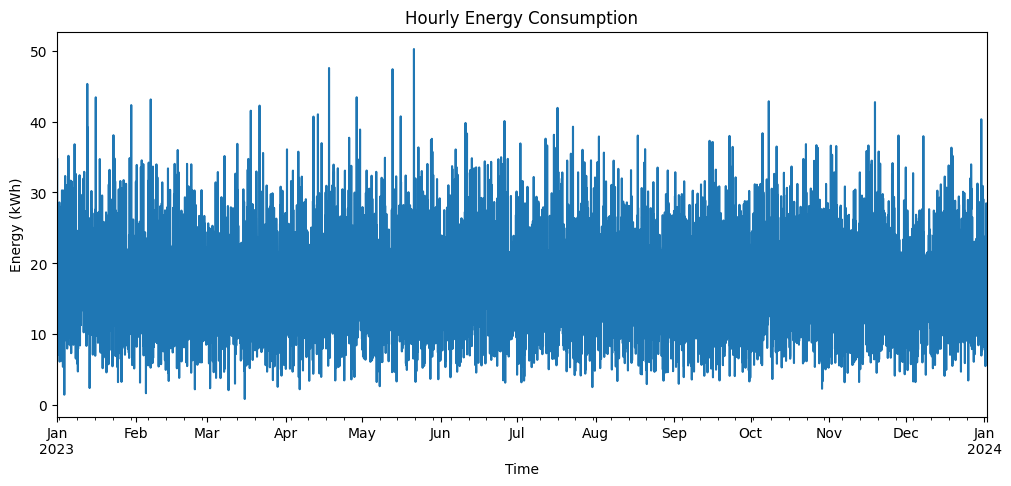

In [ ]:
hourly = df.resample('H')['Energy Consumption (kWh)'].sum()

plt.figure(figsize=(12,5))
hourly.plot()
plt.title("Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.show()


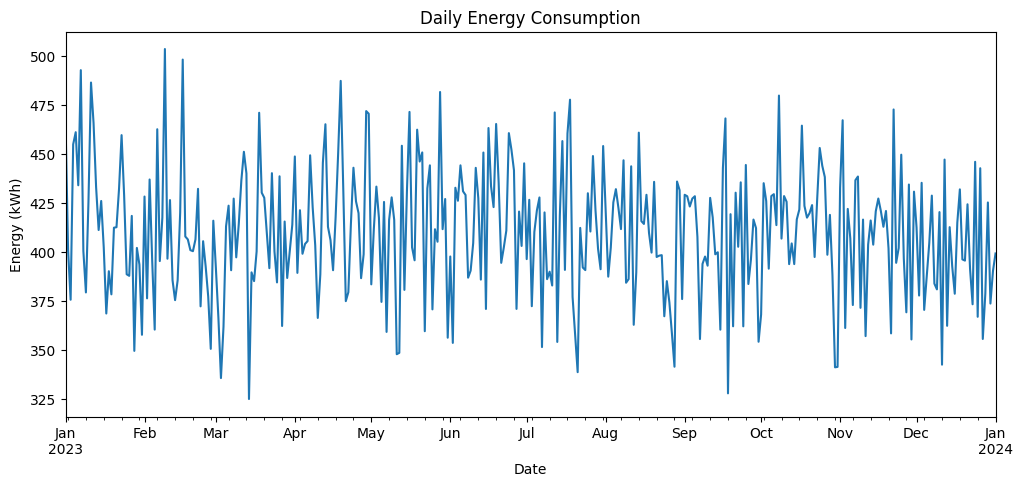

In [ ]:
daily = df.resample('D')['Energy Consumption (kWh)'].sum()

plt.figure(figsize=(12,5))
daily.plot()
plt.title("Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.show()


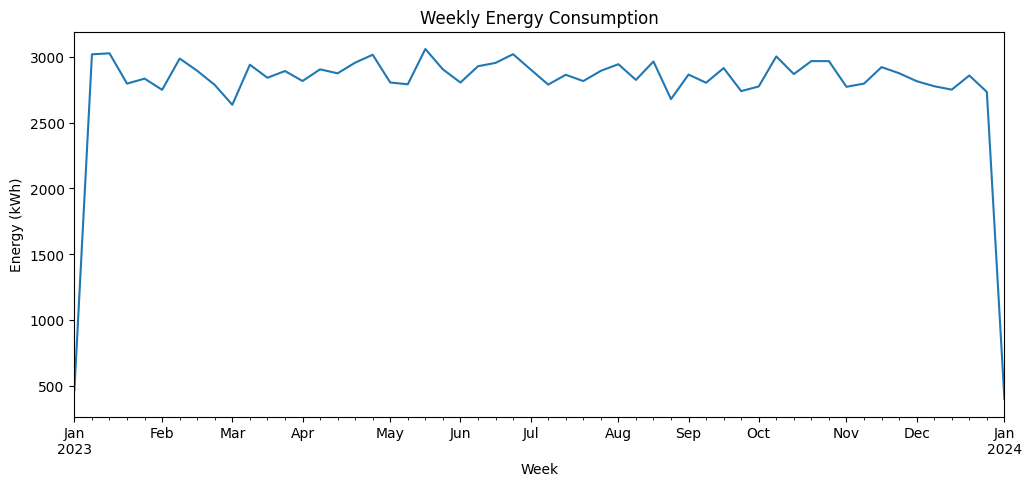

In [ ]:
weekly = df.resample('W')['Energy Consumption (kWh)'].sum()

plt.figure(figsize=(12,5))
weekly.plot()
plt.title("Weekly Energy Consumption")
plt.xlabel("Week")
plt.ylabel("Energy (kWh)")
plt.show()


/tmp/ipython-input-4275529271.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M')['Energy Consumption (kWh)'].sum()


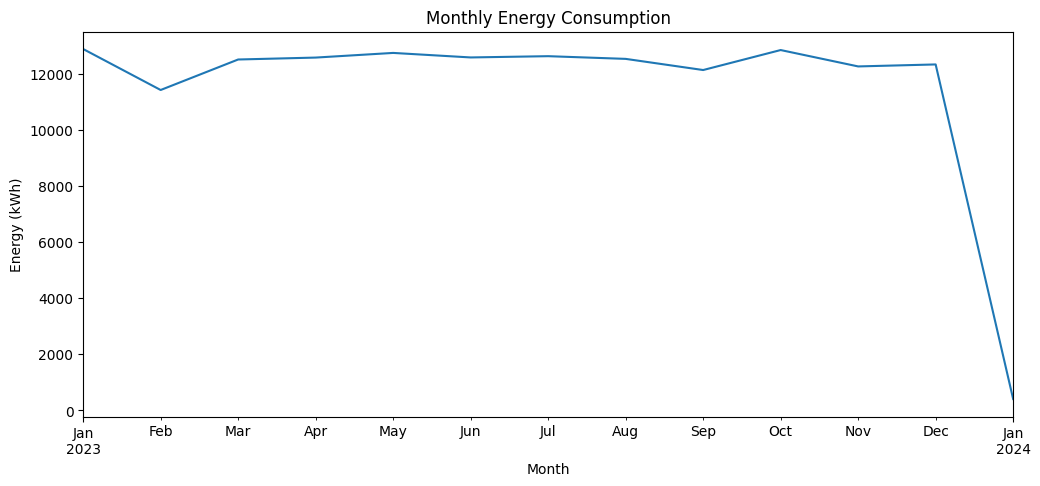

In [ ]:
monthly = df.resample('M')['Energy Consumption (kWh)'].sum()

plt.figure(figsize=(12,5))
monthly.plot()
plt.title("Monthly Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.show()


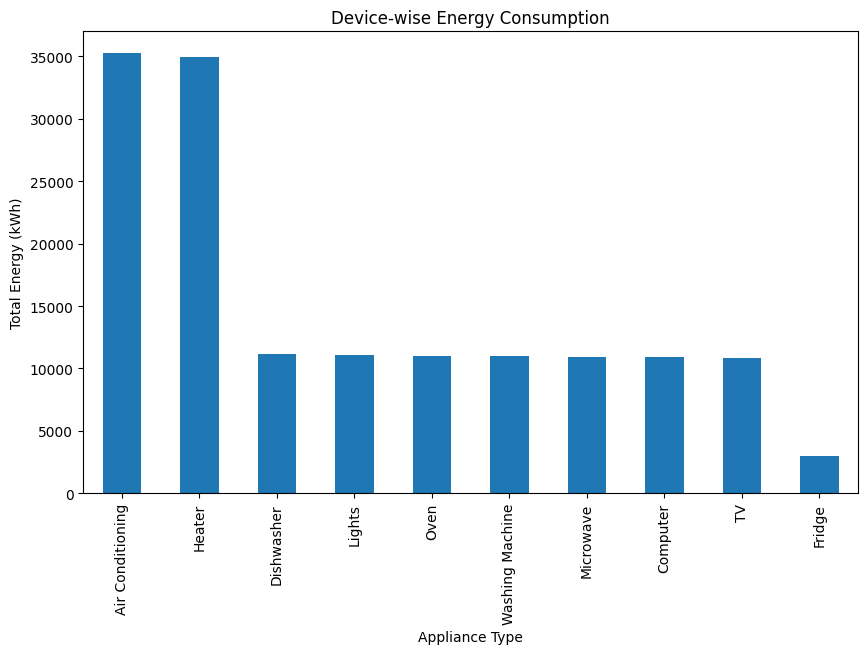

In [ ]:
device_usage = df.groupby('Appliance Type')['Energy Consumption (kWh)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
device_usage.plot(kind='bar')
plt.title("Device-wise Energy Consumption")
plt.ylabel("Total Energy (kWh)")
plt.show()

In [ ]:
def generate_smart_suggestions(df):
    suggestions = []

    # High peak usage detection
    peak = df['Energy Consumption (kWh)'].max()
    avg = df['Energy Consumption (kWh)'].mean()

    if peak > avg * 1.5:
        suggestions.append("⚠ High peak energy usage detected. Avoid running heavy appliances simultaneously.")

    # Device-level analysis
    device_usage = df.groupby('Appliance Type')['Energy Consumption (kWh)'].sum()
    highest_device = device_usage.idxmax()

    suggestions.append(f"💡 {highest_device} consumes the most energy. Consider reducing its usage during peak hours.")

    # Night-time usage check
    night_usage = df[df.index.hour >= 22]['Energy Consumption (kWh)'].mean()
    if night_usage > avg:
        suggestions.append("🌙 High night-time consumption detected. Turn off unused devices before sleep.")

    # Weekend pattern
    weekend_usage = df[df.index.dayofweek >= 5]['Energy Consumption (kWh)'].mean()
    if weekend_usage > avg:
        suggestions.append("📅 Weekend consumption is high. Monitor entertainment and AC usage.")

    return suggestions

In [ ]:
tips = generate_smart_suggestions(df)

print("SMART ENERGY SAVING SUGGESTIONS:")
for tip in tips:
    print("-", tip)


SMART ENERGY SAVING SUGGESTIONS:
- ⚠ High peak energy usage detected. Avoid running heavy appliances simultaneously.
- 💡 Air Conditioning consumes the most energy. Consider reducing its usage during peak hours.
- 🌙 High night-time consumption detected. Turn off unused devices before sleep.


In [ ]:
tips = generate_smart_suggestions(df)

print("SMART ENERGY SAVING SUGGESTIONS:")
for tip in tips:
    print("-", tip)


SMART ENERGY SAVING SUGGESTIONS:
- ⚠ High peak energy usage detected. Avoid running heavy appliances simultaneously.
- 💡 Air Conditioning consumes the most energy. Consider reducing its usage during peak hours.
- 🌙 High night-time consumption detected. Turn off unused devices before sleep.


In [ ]:
print(type(scaler))


<class 'sklearn.preprocessing._data.MinMaxScaler'>


In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [ ]:
from google.colab import files
files.download("scaler.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>